In [163]:
import json
import matplotlib.pyplot as plt
import pandas as pd

In [164]:
offshore_gemini_df = pd.read_csv("../datasets/offshore_Gemini.csv", index_col=0, parse_dates=True)
entso_timeseries_df = pd.read_csv("../datasets/ENTSO_power_time_series.csv", index_col=0, parse_dates=True)
with open("../datasets/wind_farms_new.json") as f:
    wind_farms = json.load(f)["wind_farms"]

In [165]:
# Build a capacity timeline
df_farms = pd.DataFrame(wind_farms)
df_farms["commissioned"] = pd.to_datetime(df_farms["commissioned"], dayfirst=True)
df_farms["installed_capacity_mw"] = pd.to_numeric(df_farms["installed_capacity_mw"])

# Sort by commission date and calculate cumulative capacity
df_farms = df_farms.sort_values("commissioned")
df_farms["cumulative_capacity"] = df_farms["installed_capacity_mw"].cumsum()


start_date = entso_timeseries_df.index.min()

# Filter farms commissioned before the start of the data
df_farms_filtered = df_farms[df_farms["commissioned"] >= start_date].copy()

# Recalculate cumulative capacity starting from whatever was already installed at start_date
baseline_capacity = df_farms[df_farms["commissioned"] < start_date]["installed_capacity_mw"].sum()
df_farms_filtered["cumulative_capacity"] = baseline_capacity + df_farms_filtered["installed_capacity_mw"].cumsum()

# Extend the step line
end_date = entso_timeseries_df.index.max()

max_capacity = df_farms_filtered["cumulative_capacity"].max()
commissioned_extended = pd.concat([pd.Series([start_date]), df_farms_filtered["commissioned"], pd.Series([end_date])])
capacity_extended = pd.concat([pd.Series([baseline_capacity]), df_farms_filtered["cumulative_capacity"], pd.Series([max_capacity])])

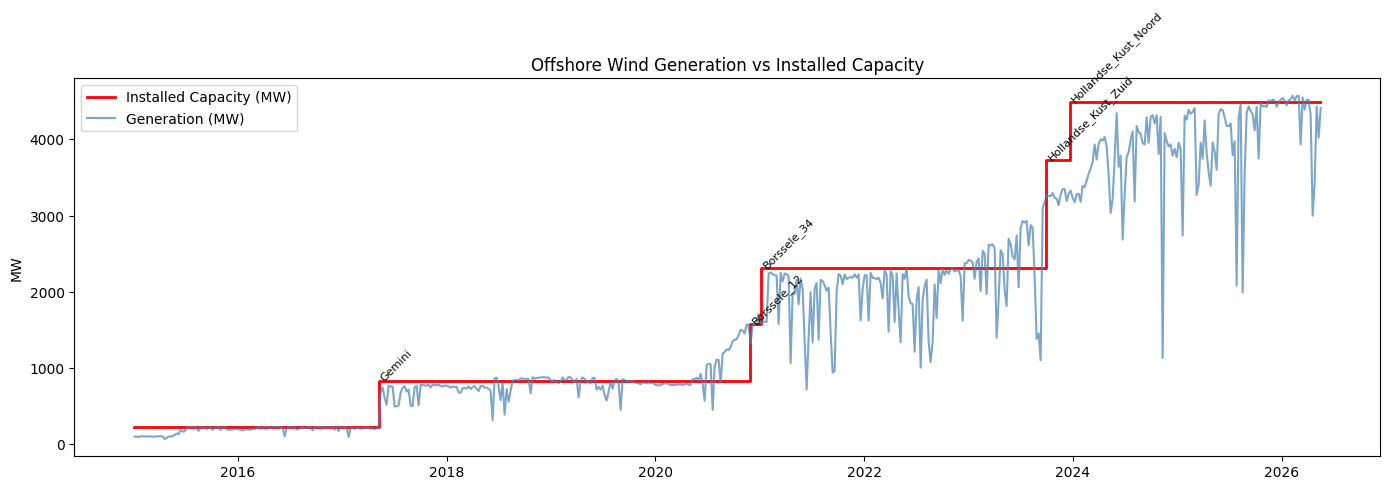

In [166]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")

daily_max = entso_timeseries_df["Generation_MW"].resample("W").max()

ax.plot(daily_max.index, daily_max, color="steelblue", alpha=0.7, label="Generation (MW)")
#ax.plot(entso_timeseries_df.index, entso_timeseries_df["Generation_MW"], color="steelblue", alpha=0.7, label="Generation (MW)")

for _, row in df_farms.iterrows():
    ax.annotate(row["name"], xy=(row["commissioned"], row["cumulative_capacity"]),
                fontsize=8, rotation=45)

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [167]:
offshore_gemini_df["Power"].max()

np.float64(600.0)

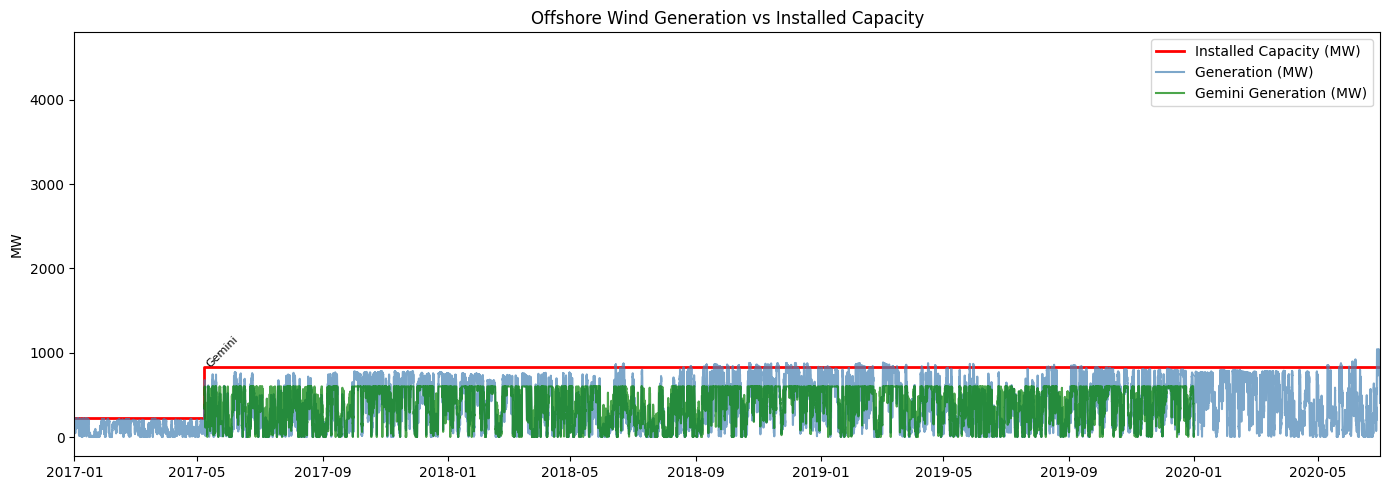

In [168]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")

ax.plot(entso_timeseries_df.index, entso_timeseries_df["Generation_MW"], color="steelblue", alpha=0.7, label="Generation (MW)")

# Gemini individual generation
gemini_start = df_farms[df_farms["name"] == "Gemini"]["commissioned"].values[0]
ax.plot(offshore_gemini_df[offshore_gemini_df.index >= gemini_start]["Power"], color="green", alpha=0.7, label="Gemini Generation (MW)")

for _, row in df_farms.iterrows():
    ax.annotate(row["name"], xy=(row["commissioned"], row["cumulative_capacity"]),
                fontsize=8, rotation=45)

ax.set_xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2020-07-01"))
ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [169]:
# Calculate median generation before Gemini was commissioned
baseline_start = pd.Timestamp("2016-01-01")

pre_gemini_median = entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
]["Generation_MW"].mean()

pre_gemini_max = entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
]["Generation_MW"].max()

print("Pre Gemini median of power production:", pre_gemini_median)
print("Pre Gemini max of power production:", pre_gemini_max)



Pre Gemini median of power production: 96.18148168103448
Pre Gemini max of power production: 229.865


In [170]:
gemini_period_df = entso_timeseries_df[
    (entso_timeseries_df.index >= gemini_start) &
    (entso_timeseries_df.index < "2020-01-01")
].copy()

gemini_period_df["Generation_excl_baseline_entso"] = (gemini_period_df["Generation_MW"] * (600 / (600 + pre_gemini_max)))
gemini_period_df["Generation_offshore"] = offshore_gemini_df.loc[
    (offshore_gemini_df.index >= gemini_start) &
    (offshore_gemini_df.index < "2020-01-01"),
    "Power"
]

In [171]:
gemini_period_df

,Generation_MW,Generation_excl_baseline_entso,Generation_offshore
Datetime,,,
2017-05-08 00:00:00,346.3625,250.423262,380.585540
2017-05-08 01:00:00,297.7425,215.270556,358.059540
2017-05-08 02:00:00,279.7725,202.278081,333.529500
2017-05-08 03:00:00,217.5150,157.265338,366.451540
2017-05-08 04:00:00,199.9375,144.556645,449.258700
...,...,...,...
2019-12-31 19:00:00,7.8650,5.686467,11.280157
2019-12-31 20:00:00,16.9300,12.240545,0.000000
2019-12-31 21:00:00,30.0025,21.692082,0.000000


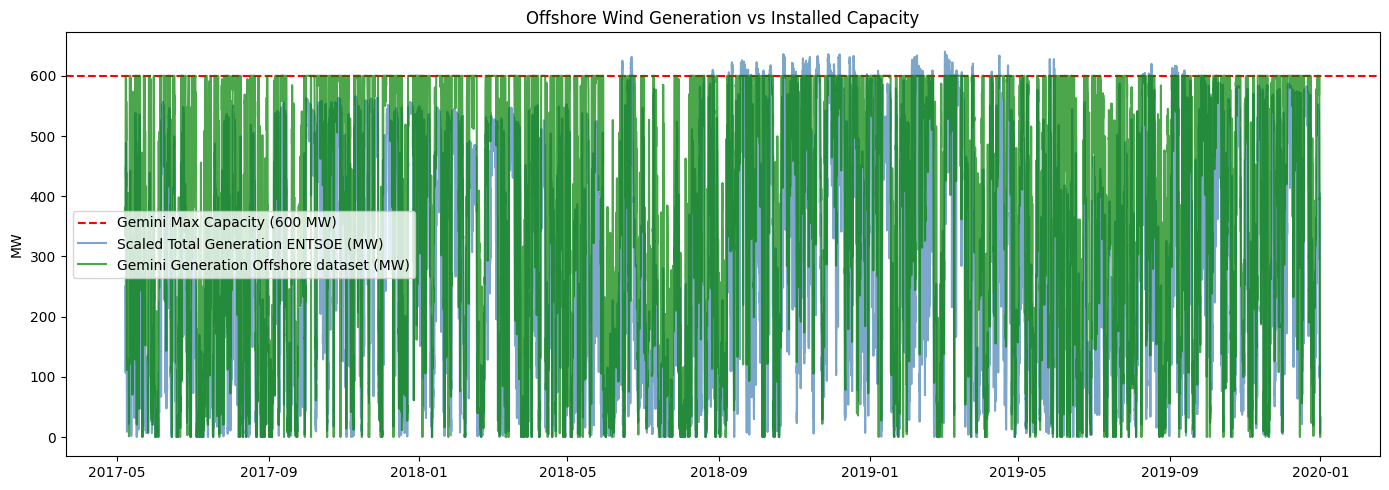

In [172]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df.index, gemini_period_df["Generation_excl_baseline_entso"], color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

# Gemini individual generation
ax.plot(gemini_period_df.index, gemini_period_df["Generation_offshore"], color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [173]:
from sklearn.metrics import mean_absolute_error
import numpy as np

mae = mean_absolute_error(gemini_period_df["Generation_excl_baseline_entso"], gemini_period_df["Generation_offshore"])
rmse = np.sqrt(((gemini_period_df["Generation_offshore"] - gemini_period_df["Generation_excl_baseline_entso"])**2).mean())
correlation = gemini_period_df["Generation_offshore"].corr(gemini_period_df["Generation_excl_baseline_entso"])
print(f"mae: {mae}, rmse: {rmse}, correlation: {correlation}")

mae: 141.2903640223761, rmse: 173.26287914951928, correlation: 0.856269737619497


count    23232.000000
mean       135.737806
std        107.683669
min       -552.066300
25%         54.221384
50%        126.673013
75%        210.692303
max        581.049930
Name: error, dtype: float64


<Axes: xlabel='Datetime'>

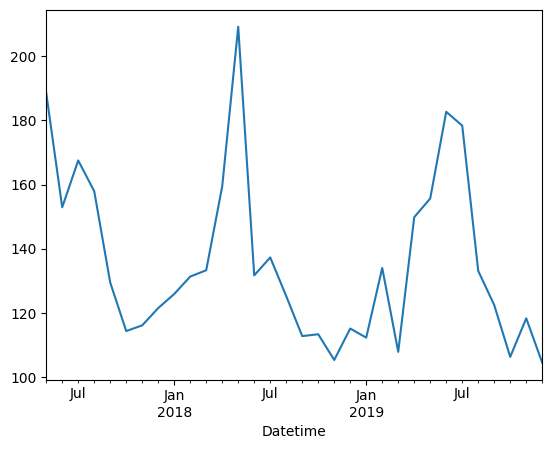

In [174]:
gemini_period_df["error"] = (
    gemini_period_df["Generation_offshore"] -
    gemini_period_df["Generation_excl_baseline_entso"]
)

# Check if error is systematic
print(gemini_period_df["error"].describe())

# Plot error over time to see if it is worse in certain periods
gemini_period_df["error"].resample("ME").mean().plot()

<Axes: xlabel='Datetime'>

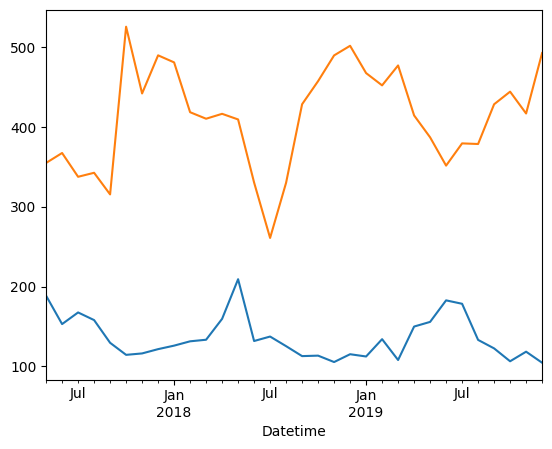

In [175]:
gemini_period_df["error"].resample("ME").mean().plot()
gemini_period_df["Generation_offshore"].resample("ME").mean().plot()

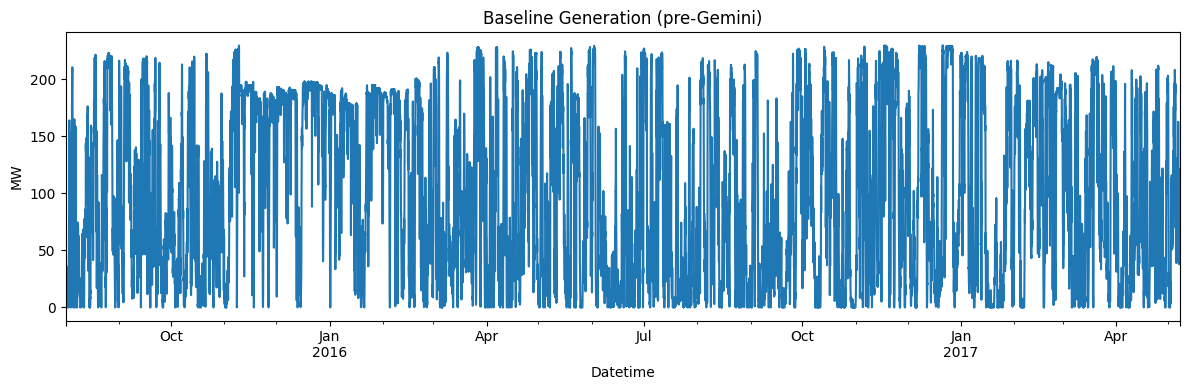

In [176]:
baseline_start = pd.Timestamp("2015-08-01")

entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
]["Generation_MW"].plot(figsize=(12, 4))

plt.title("Baseline Generation (pre-Gemini)")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

In [177]:
monthly_median = entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
].groupby(entso_timeseries_df[
    (entso_timeseries_df.index >= baseline_start) &
    (entso_timeseries_df.index < gemini_start)
].index.month)["Generation_MW"].median()

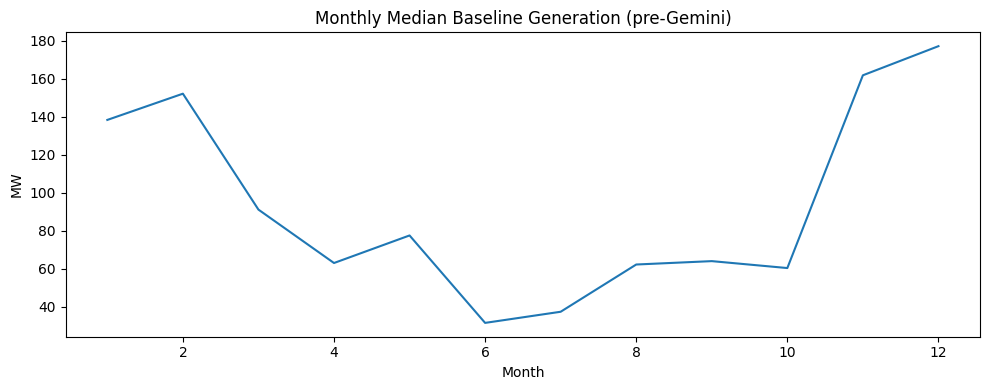

In [178]:
monthly_median.plot(figsize=(10, 4))
plt.xlabel("Month")
plt.ylabel("MW")
plt.title("Monthly Median Baseline Generation (pre-Gemini)")
plt.tight_layout()
plt.show()

In [179]:
gemini_period_df["Generation_excl_baseline_monthly"] = gemini_period_df.apply(
    lambda row: row["Generation_MW"] - monthly_median[row.name.month], axis=1
)

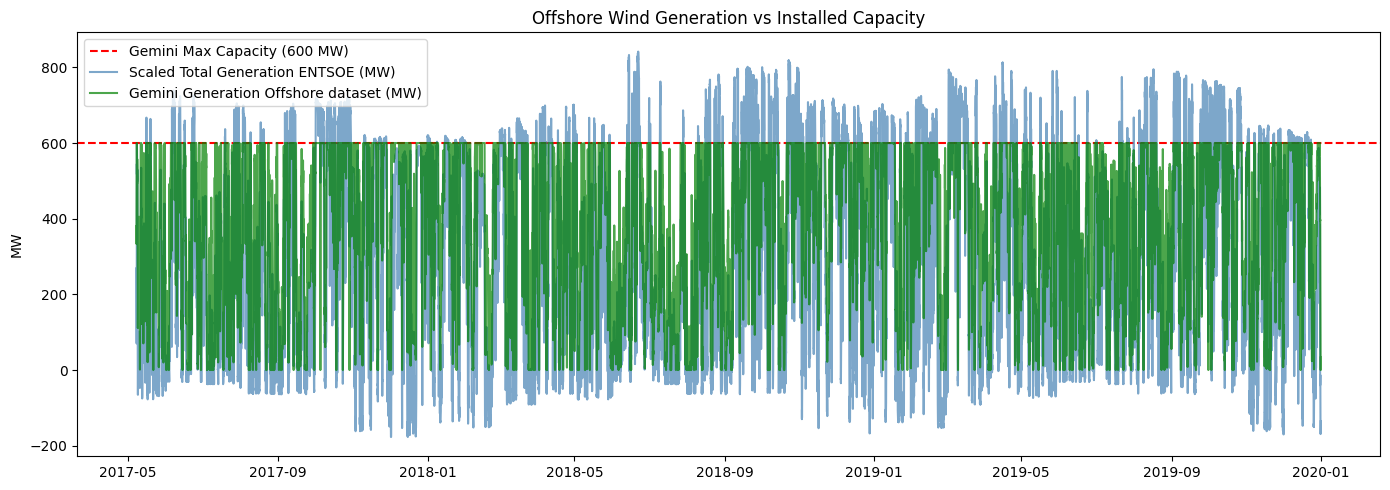

In [180]:
# Plot
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df.index, gemini_period_df["Generation_excl_baseline_monthly"], color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

# Gemini individual generation
ax.plot(gemini_period_df.index, gemini_period_df["Generation_offshore"], color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [181]:
mae = mean_absolute_error(gemini_period_df["Generation_excl_baseline_monthly"], gemini_period_df["Generation_offshore"])
rmse = np.sqrt(((gemini_period_df["Generation_offshore"] - gemini_period_df["Generation_excl_baseline_monthly"])**2).mean())
correlation = gemini_period_df["Generation_offshore"].corr(gemini_period_df["Generation_excl_baseline_monthly"])
print(f"mae: {mae}, rmse: {rmse}, correlation: {correlation}")

mae: 153.95207336848674, rmse: 187.6606937249003, correlation: 0.847407407349357


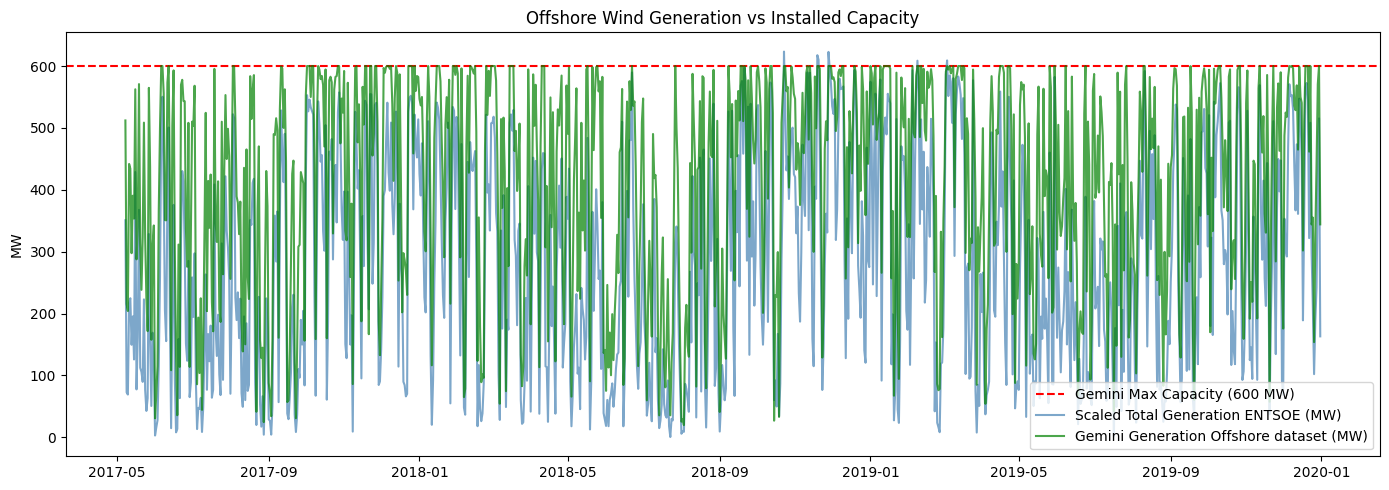

In [182]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_excl_baseline_entso"].resample("D").mean(),
        color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore"].resample("D").mean(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

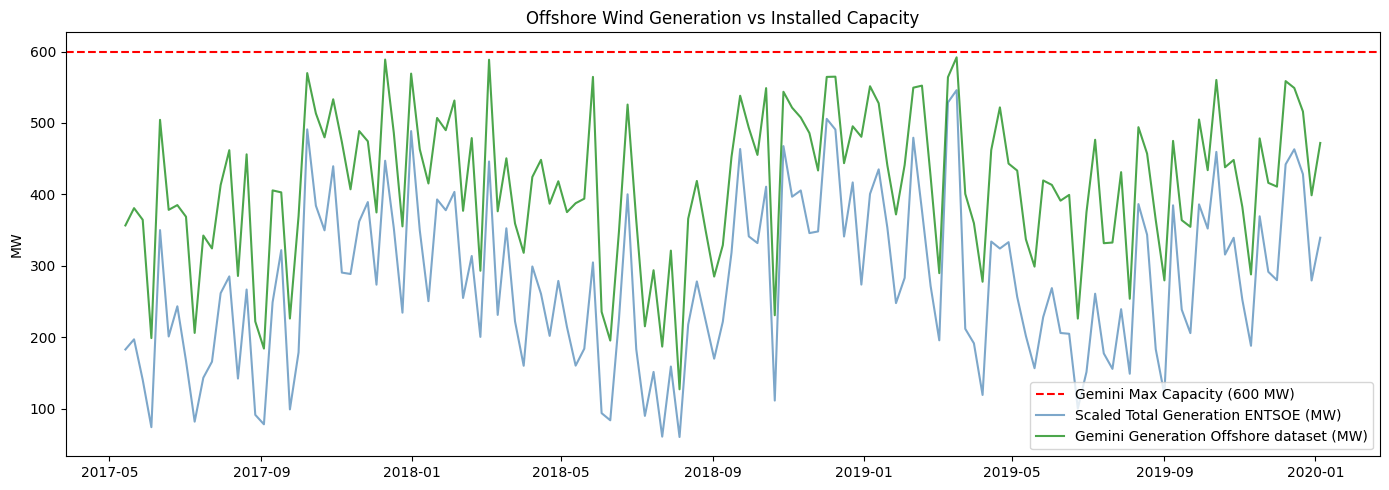

In [183]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_excl_baseline_entso"].resample("W").mean(),
        color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore"].resample("W").mean(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [184]:
# Calculate monthly median of baseline period
# baseline = entso_timeseries_df[
#     (entso_timeseries_df.index >= baseline_start) &
#     (entso_timeseries_df.index < gemini_start)
# ]
# monthly_baseline_median = baseline.groupby(baseline.index.month)["Generation_MW"].median()
#
# # Scale each row by subtracting the monthly baseline first, then clip negatives
# gemini_period_df["Generation_excl_baseline_monthly"] = gemini_period_df.apply(
#     lambda row: (row["Generation_MW"] - monthly_baseline_median[row.name.month]) *
#                 (600 / (600 + pre_gemini_max - monthly_baseline_median[row.name.month])),
#     axis=1
# )

In [185]:
# fig, ax = plt.subplots(figsize=(14, 5))
#
# ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")
#
# ax.plot(gemini_period_df["Generation_excl_baseline_monthly"].resample("W").mean(),
#         color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE monthly corrected (MW)")
#
# ax.plot(gemini_period_df["Generation_offshore"].resample("W").mean(),
#         color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")
#
# ax.set_ylabel("MW")
# ax.legend()
# plt.title("Offshore Wind Generation vs Installed Capacity (monthly baseline corrected)")
# plt.tight_layout()
# plt.show()

In [186]:
# mae = mean_absolute_error(gemini_period_df["Generation_excl_baseline_monthly"], gemini_period_df["Generation_offshore"])
# rmse = np.sqrt(((gemini_period_df["Generation_offshore"] - gemini_period_df["Generation_excl_baseline_monthly"])**2).mean())
# correlation = gemini_period_df["Generation_offshore"].corr(gemini_period_df["Generation_excl_baseline_monthly"])
# print(f"mae: {mae}, rmse: {rmse}, correlation: {correlation}")

In [187]:
scaling_factor = gemini_period_df["Generation_excl_baseline_entso"].mean() / gemini_period_df["Generation_offshore"].mean()
print(f"Scaling factor: {scaling_factor}")

Scaling factor: 0.6713570741253015


In [206]:
gemini_period_df["Generation_offshore_scaled"] = gemini_period_df["Generation_offshore"] * scaling_factor

# Recompute metrics
mae_scaled = mean_absolute_error(gemini_period_df["Generation_offshore_scaled"], gemini_period_df["Generation_excl_baseline_entso"])
correlation_scaled = gemini_period_df["Generation_offshore_scaled"].corr(gemini_period_df["Generation_excl_baseline_entso"])
print(f"MAE after scaling: {mae_scaled}, correlation: {correlation_scaled}")

MAE after scaling: 89.98652156478289, correlation: 0.8562697376194977


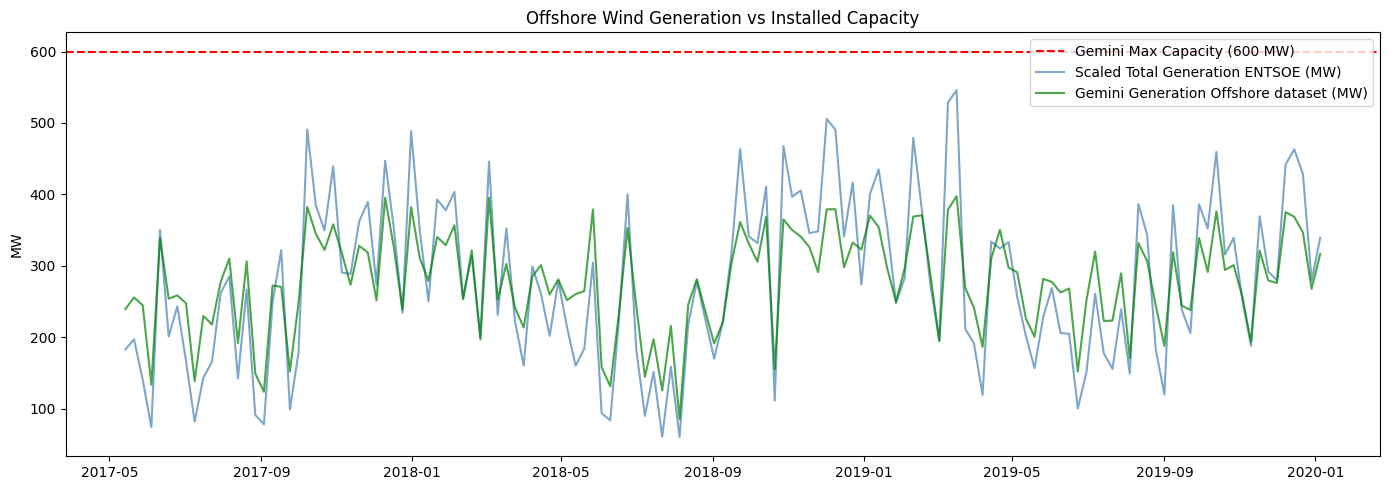

In [207]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.axhline(y=600, color="red", linewidth=1.5, linestyle="--", label="Gemini Max Capacity (600 MW)")

ax.plot(gemini_period_df["Generation_excl_baseline_entso"].resample("W").mean(),
        color="steelblue", alpha=0.7, label="Scaled Total Generation ENTSOE (MW)")

ax.plot(gemini_period_df["Generation_offshore_scaled"].resample("W").mean(),
        color="green", alpha=0.7, label="Gemini Generation Offshore dataset (MW)")

ax.set_ylabel("MW")
ax.legend()
plt.title("Offshore Wind Generation vs Installed Capacity")
plt.tight_layout()
plt.show()

In [210]:
for freq in ["h", "D", "W", "ME"]:
    entso_resampled = gemini_period_df["Generation_excl_baseline_entso"].resample(freq).mean()
    offshore_resampled = gemini_period_df["Generation_offshore"].resample(freq).mean()

    # Drop NaNs for the comparison
    mask = entso_resampled.notna() & offshore_resampled.notna()

    r = entso_resampled[mask].corr(offshore_resampled[mask])
    mae = mean_absolute_error(entso_resampled[mask], offshore_resampled[mask])
    rmse = np.sqrt(((entso_resampled[mask] - offshore_resampled[mask])**2).mean())

    print(f"{freq}: correlation: {r:.3f}, MAE: {mae:.1f}, RMSE: {rmse:.1f}")

h: correlation: 0.856, MAE: 141.3, RMSE: 173.3
D: correlation: 0.911, MAE: 136.3, RMSE: 153.9
W: correlation: 0.938, MAE: 135.7, RMSE: 141.5
ME: correlation: 0.960, MAE: 136.1, RMSE: 138.6


In [ ]:
# MAE consitent therefore errro probaly systematic (offset)

In [211]:
for freq in ["h", "D", "W", "ME"]:
    entso_resampled = gemini_period_df["Generation_excl_baseline_entso"].resample(freq).mean()
    offshore_resampled = gemini_period_df["Generation_offshore_scaled"].resample(freq).mean()

    # Drop NaNs for the comparison
    mask = entso_resampled.notna() & offshore_resampled.notna()

    r = entso_resampled[mask].corr(offshore_resampled[mask])
    mae = mean_absolute_error(entso_resampled[mask], offshore_resampled[mask])
    rmse = np.sqrt(((entso_resampled[mask] - offshore_resampled[mask])**2).mean())

    print(f"{freq}: correlation: {r:.3f}, MAE: {mae:.1f}, RMSE: {rmse:.1f}")

h: correlation: 0.856, MAE: 90.0, RMSE: 109.3
D: correlation: 0.911, MAE: 69.4, RMSE: 84.6
W: correlation: 0.938, MAE: 46.6, RMSE: 55.9
ME: correlation: 0.960, MAE: 36.5, RMSE: 41.3
